# Проверка правил контроля качества DXA

Этот ноутбук воспроизводит эксперименты с правилами из `DXA_target_algorithms_tuning.ipynb` и сравнивает новые простые признаки. Он использует сохранённые признаки из `prototype_output/target_tuning/` и текущие метки `разметка.xlsx`. Запускайте ячейки сверху вниз командой **Run All**.

**Как читать результат:** для новых правил порог подбирается на обучающих исследованиях каждого фолда, а прогноз оценивается на других исследованиях. Строки `notebook_full_data_params` используют ранее выбранные на всей выборке параметры и показаны только для ориентира. После перебора гипотез эта оценка остаётся исследовательской, не финальным независимым тестом.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay

here = Path.cwd()
if (here / 'dxa_project' / 'rule_experiments.py').exists():
    project_dir = here / 'dxa_project'
elif (here / 'rule_experiments.py').exists():
    project_dir = here
else:
    raise FileNotFoundError('Откройте ноутбук из корня Хакатон или папки dxa_project')
sys.path.insert(0, str(project_dir))
import rule_experiments as experiment

print('Проект:', project_dir.resolve())
print('Признаки:', experiment.CACHE)


Проект: C:\Users\Андрей\Desktop\Хакатон\dxa_project
Признаки: C:\Users\Андрей\Desktop\Хакатон\prototype_output\target_tuning


## 1. Пересчитать прогнозы

Ячейка проверяет, что сохранённые таргеты совпадают с текущим Excel, затем выполняет групповую проверку по исследованиям. Для этого этапа DICOM и GPU не нужны. Результаты сохраняются в `dxa_project/outputs/rule_experiments/`.

In [2]:
import contextlib
import io

with contextlib.redirect_stdout(io.StringIO()):
    experiment.main()
metrics = pd.read_csv(experiment.OUT / 'metrics.csv')
predictions = pd.read_csv(experiment.OUT / 'predictions.csv')
print(f'Готово: {len(metrics)} вариантов правил, {len(predictions)} прогнозов по вариантам.')
display(metrics[['target', 'rule', 'evaluation', 'n', 'positives', 'tp', 'fn', 'fp', 'tn',
                 'sensitivity', 'specificity', 'balanced_accuracy']].round(3))


Готово: 30 вариантов правил, 3754 прогнозов по вариантам.


,target,rule,evaluation,n,positives,tp,fn,fp,tn,sensitivity,specificity,balanced_accuracy
0,spine_coverage,notebook_full_data_params,full_data_tuned_baseline,99,6,6,0,56,37,1.000,0.398,0.699
1,spine_coverage,high:t12_half_ratio,study_group_oof,99,6,3,3,28,65,0.500,0.699,0.599
2,spine_coverage,high:bright_threshold,study_group_oof,99,6,3,3,11,82,0.500,0.882,0.691
3,spine_coverage,low:separator_median_gap_px,study_group_oof,99,6,4,2,24,69,0.667,0.742,0.704
4,spine_coverage,low:iliac_left_image_area_fraction,study_group_oof,99,6,4,2,34,59,0.667,0.634,0.651
5,spine_coverage,low:separator_median_gap_ratio,study_group_oof,99,6,4,2,36,57,0.667,0.613,0.640
6,spine_alignment,fixed_5_degrees,fixed_rule,99,10,7,3,22,67,0.700,0.753,0.726
7,spine_alignment,high:axis_deviation_vertical_deg_boundary,study_group_oof,99,10,7,3,29,60,0.700,0.674,0.687
8,spine_alignment,high:axis_deviation_vertical_deg_symmetry,study_group_oof,99,10,4,6,26,63,0.400,0.708,0.554
9,spine_alignment,high:axis_deviation_vertical_deg_brightness,study_group_oof,99,10,8,2,78,11,0.800,0.124,0.462


## 2. Сравнение основных гипотез

Ниже показаны прежние правила и наиболее интересные новые варианты. Для позвоночной оси используется заданный в постановке порог 5°. Обратите внимание на число положительных случаев в таблице выше.

,target,rule,evaluation,tp,fn,fp,tn,sensitivity,specificity,balanced_accuracy
0,spine_coverage,notebook_full_data_params,full_data_tuned_baseline,6,0,56,37,1.000,0.398,0.699
3,spine_coverage,low:separator_median_gap_px,study_group_oof,4,2,24,69,0.667,0.742,0.704
6,spine_alignment,fixed_5_degrees,fixed_rule,7,3,22,67,0.700,0.753,0.726
7,spine_alignment,high:axis_deviation_vertical_deg_boundary,study_group_oof,7,3,29,60,0.700,0.674,0.687
10,spine_artifacts,notebook_full_data_params,full_data_tuned_baseline,12,5,30,52,0.706,0.634,0.670
11,spine_artifacts,high:artifact_border_bright_fraction,study_group_oof,11,6,36,46,0.647,0.561,0.604
14,hip_position_rotation,notebook_full_data_params,full_data_tuned_baseline,27,8,82,31,0.771,0.274,0.523
20,hip_position_rotation,high:trochanter_best_offset_ratio,study_group_oof,27,8,56,57,0.771,0.504,0.638
23,hip_roi,notebook_full_data_params,full_data_tuned_baseline,0,6,22,120,0.000,0.845,0.423
24,hip_roi,low:roi_bottom_margin_ratio,study_group_oof,3,3,10,132,0.500,0.930,0.715


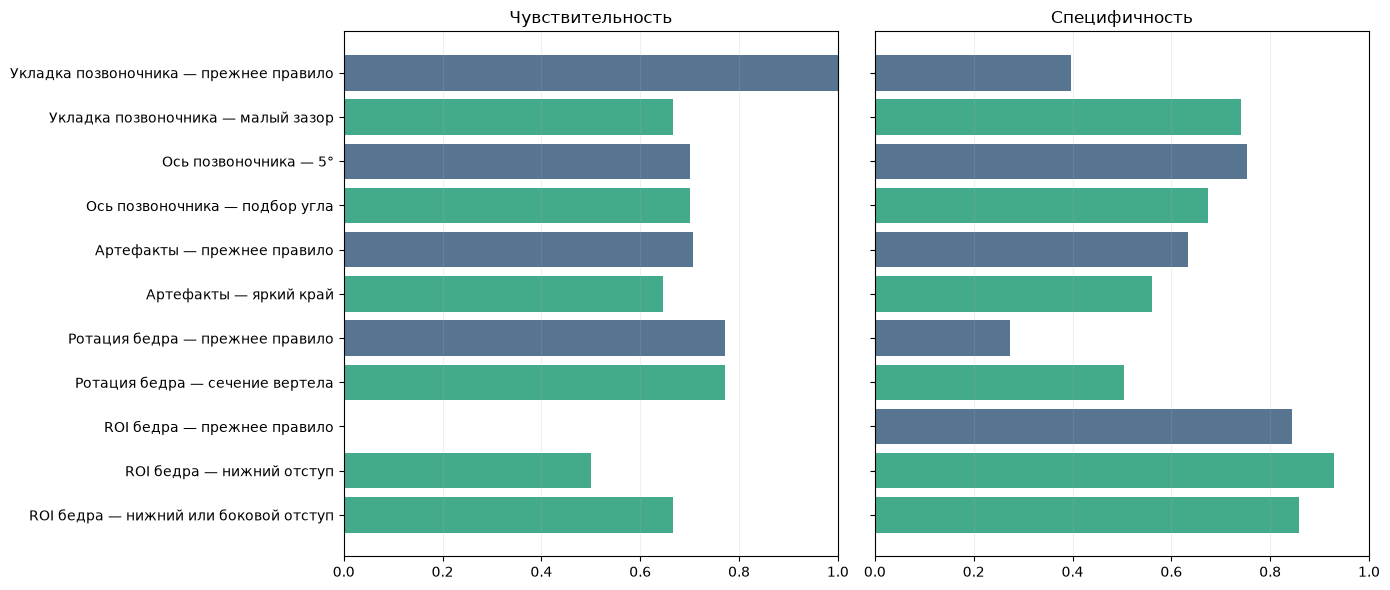

In [3]:
selected = {
    'spine_coverage': ['notebook_full_data_params', 'low:separator_median_gap_px'],
    'spine_alignment': ['fixed_5_degrees', 'high:axis_deviation_vertical_deg_boundary'],
    'spine_artifacts': ['notebook_full_data_params', 'high:artifact_border_bright_fraction'],
    'hip_position_rotation': ['notebook_full_data_params', 'high:trochanter_best_offset_ratio'],
    'hip_roi': ['notebook_full_data_params',
                'or_low:roi_bottom_margin_ratio+roi_lateral_margin_ratio',
                'low:roi_bottom_margin_ratio'],
}
summary = metrics[metrics.apply(lambda row: row['rule'] in selected.get(row['target'], []), axis=1)].copy()
display(summary[['target', 'rule', 'evaluation', 'tp', 'fn', 'fp', 'tn',
                 'sensitivity', 'specificity', 'balanced_accuracy']].round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
plot = summary.reset_index(drop=True)
task_names = {'spine_coverage': 'Укладка позвоночника', 'spine_alignment': 'Ось позвоночника',
              'spine_artifacts': 'Артефакты', 'hip_position_rotation': 'Ротация бедра',
              'hip_roi': 'ROI бедра'}
rule_names = {'notebook_full_data_params': 'прежнее правило', 'fixed_5_degrees': '5°',
              'low:separator_median_gap_px': 'малый зазор',
              'high:axis_deviation_vertical_deg_boundary': 'подбор угла',
              'high:artifact_border_bright_fraction': 'яркий край',
              'high:trochanter_best_offset_ratio': 'сечение вертела',
              'low:roi_bottom_margin_ratio': 'нижний отступ',
              'or_low:roi_bottom_margin_ratio+roi_lateral_margin_ratio': 'нижний или боковой отступ'}
labels = [f"{task_names[r.target]} — {rule_names.get(r.rule, r.rule)}" for r in plot.itertuples()]
y = range(len(plot))
for ax, key, title in zip(axes,
                          ['sensitivity', 'specificity'],
                          ['Чувствительность', 'Специфичность']):
    bars = ax.barh(y, plot[key], color=['#577590' if 'baseline' in e or e == 'fixed_rule' else '#43aa8b'
                                          for e in plot['evaluation']])
    ax.set_xlim(0, 1)
    ax.set_title(title)
    ax.grid(axis='x', alpha=.2)
axes[0].set_yticks(list(y), labels)
axes[0].invert_yaxis()
axes[1].tick_params(axis='y', labelleft=False)
fig.tight_layout()
plt.show()


## 3. Насколько менялись пороги между фолдами

`full_fit_parameters` — параметры, подобранные по всем доступным исследованиям для будущей проверки. Они не используются для расчёта OOF метрик.

In [4]:
interesting = [
    'low:separator_median_gap_px',
    'high:trochanter_best_offset_ratio',
    'low:roi_bottom_margin_ratio',
    'or_low:roi_bottom_margin_ratio+roi_lateral_margin_ratio',
]
for rule in interesting:
    row = metrics.loc[metrics.rule.eq(rule)].iloc[0]
    print(f"\n{row['target']} — {rule}")
    print('После обучения на всех данных:', row['full_fit_parameters'])
    display(pd.DataFrame(json.loads(row['fold_parameters'])))



spine_coverage — low:separator_median_gap_px
После обучения на всех данных: {"threshold": 42.0}


,fold,threshold
0,0,42.00
1,1,42.00
2,2,42.00
3,3,40.28
4,4,42.00



hip_position_rotation — high:trochanter_best_offset_ratio
После обучения на всех данных: {"threshold": -0.04713287836210353}


,fold,threshold
0,0,-0.064267
1,1,-0.064942
2,2,-0.051064
3,3,-0.042862
4,4,-0.045745



hip_roi — low:roi_bottom_margin_ratio
После обучения на всех данных: {"threshold": 0.3427452333707186}


,fold,threshold
0,0,0.321764
1,1,0.344013
2,2,0.357568
3,3,0.335015
4,4,0.349228



hip_roi — or_low:roi_bottom_margin_ratio+roi_lateral_margin_ratio
После обучения на всех данных: {"first": 0.3427452333707186, "second": 0.16971428571428568}


,fold,first,second
0,0,0.321764,0.171429
1,1,0.344013,0.166286
2,2,0.357568,0.171429
3,3,0.335015,0.168000
4,4,0.349228,0.168571


## 4. Просмотр ошибок конкретного правила

Измените `target` и `rule`, затем выполните ячейку. Таблица содержит пути к исходным DICOM, чтобы открыть ошибочные случаи в редакторе разметки или просмотрщике. `truth=1` означает нарушение. На диагонали матрицы — верные решения.

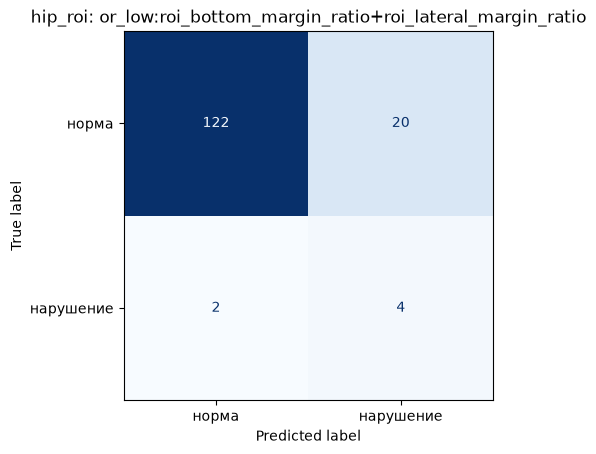

Ошибок: 22


,selection_study,dicom_path,truth,prediction
3344,2.25.132083163398091874662674590622589534350,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0,1
3349,2.25.134456506307367483341018281460841912845,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0,1
3354,2.25.13983650679559142983913935144968795415,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0,1
3362,2.25.156021661584944120526934974594604520993,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0,1
3366,2.25.156389075510671877606923458507011517218,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0,1
3371,2.25.164566280810634620154538016595892212884,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0,1
3372,2.25.164566280810634620154538016595892212884,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0,1
3380,2.25.168317503020329569414190677927680518621,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0,1
3385,2.25.173753313169335820519632380691065649420,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0,1
3386,2.25.173753313169335820519632380691065649420,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,1,0


In [5]:
target = 'hip_roi'
rule = 'or_low:roi_bottom_margin_ratio+roi_lateral_margin_ratio'

case = predictions.loc[predictions.target.eq(target) & predictions.rule.eq(rule)].copy()
if case.empty:
    raise ValueError('Нет прогнозов для выбранной пары target/rule')
ConfusionMatrixDisplay.from_predictions(case.truth, case.prediction,
                                         labels=[0, 1], display_labels=['норма', 'нарушение'],
                                         colorbar=False, cmap='Blues')
plt.title(f'{target}: {rule}')
plt.show()

errors = case.loc[case.truth.ne(case.prediction),
                  ['selection_study', 'dicom_path', 'truth', 'prediction']]
print('Ошибок:', len(errors))
display(errors.head(40))


## Выводы и ограничения

- Для ROI сочетание нижнего и бокового отступов обнаружило 4 из 6 нарушений при 20 ложных срабатываниях; прежнее правило — 0 из 6 при 22. Шесть положительных случаев дают очень широкую неопределённость.
- Нормированное смещение сечения малого вертела сохранило 27 из 35 обнаруженных нарушений бедра и уменьшило число ложных тревог с 82 до 56.
- Фиксированные 5° для оси позвоночника оказались лучше подбираемого порога на этих данных.
- Отношения к размеру кадра — экспериментальные признаки. Без проверенного физического масштаба они не подтверждают критерий 3/2 см из постановки. До внедрения нужен разбор ошибок и новая независимая выборка.

Подробный разбор находится в `dxa_project/RULE_RESULTS.md`.